# CS4082 – Lab 4: Linear Regression & Its Variants


## Part 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('all imports done')

all imports done


## Part 2 – Load and Explore the California Housing Dataset

In [2]:
# load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(f'shape: {df.shape}')
print(f'\nfeatures: {list(housing.feature_names)}')
print(f'\nfirst 5 rows:')
df.head()

shape: (20640, 9)

features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

first 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# basic statistics
df.describe().round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


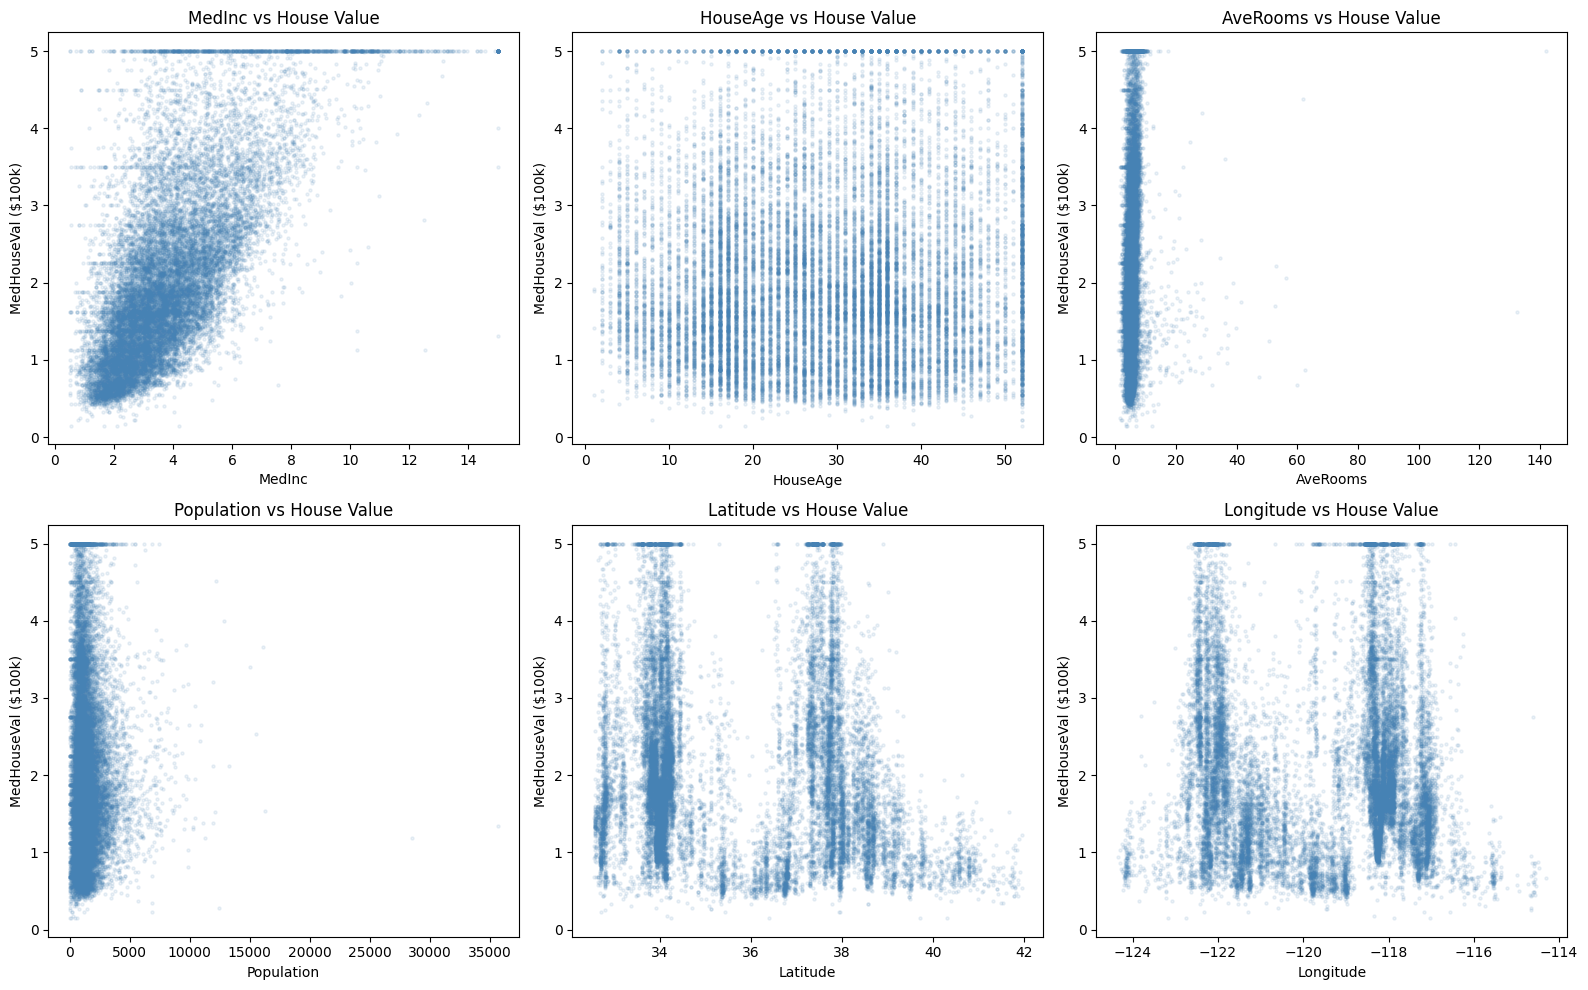

In [4]:
# scatter plots of features vs house value
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude']

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')
    ax.set_title(f'{feat} vs House Value')

plt.tight_layout()
plt.show()

### Task 1 – Explore the Dataset

In [5]:
# rank features by correlation with the target
print('correlation with MedHouseVal:')
print(df.corr()['MedHouseVal'].sort_values())

correlation with MedHouseVal:
Latitude      -0.144160
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
HouseAge       0.105623
AveRooms       0.151948
MedInc         0.688075
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64


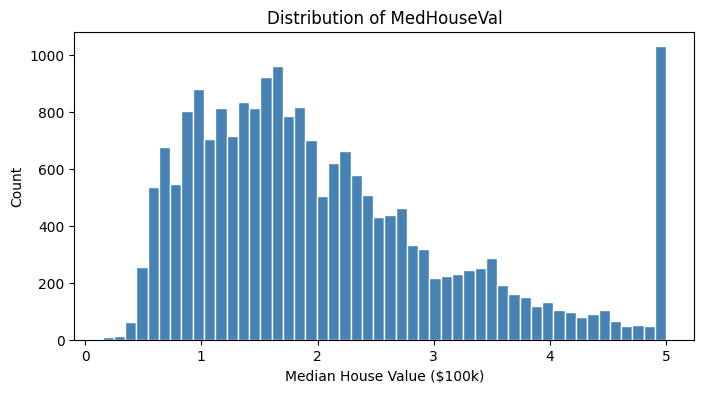

total samples: 20640


In [6]:
# distribution of target variable
plt.figure(figsize=(8, 4))
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.title('Distribution of MedHouseVal')
plt.show()

print(f'total samples: {len(df)}')

**Task 1 Answers:**

- The feature with the strongest correlation to MedHouseVal is **MedInc** .
- The distribution is not perfectly normal , it's skewed right and you can clearly see a hard cap at 5.0 ($500k), meaning a lot of houses got capped there in the data.
- There are 20,640 samples which is a decent amount more than enough to train a reliable model.

## Part 3 – Simple Linear Regression

In [7]:
# prepare data — only using MedInc
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'train: {X_train_s.shape[0]} samples')
print(f'test:  {X_test_s.shape[0]} samples')

train: 16512 samples
test:  4128 samples


In [8]:
# train the model
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)

print(f'slope  (w1): {model_simple.coef_[0]:.4f}')
print(f'intercept (w0): {model_simple.intercept_:.4f}')
print(f'\nequation: y = {model_simple.coef_[0]:.4f} * MedInc + {model_simple.intercept_:.4f}')

slope  (w1): 0.4193
intercept (w0): 0.4446

equation: y = 0.4193 * MedInc + 0.4446


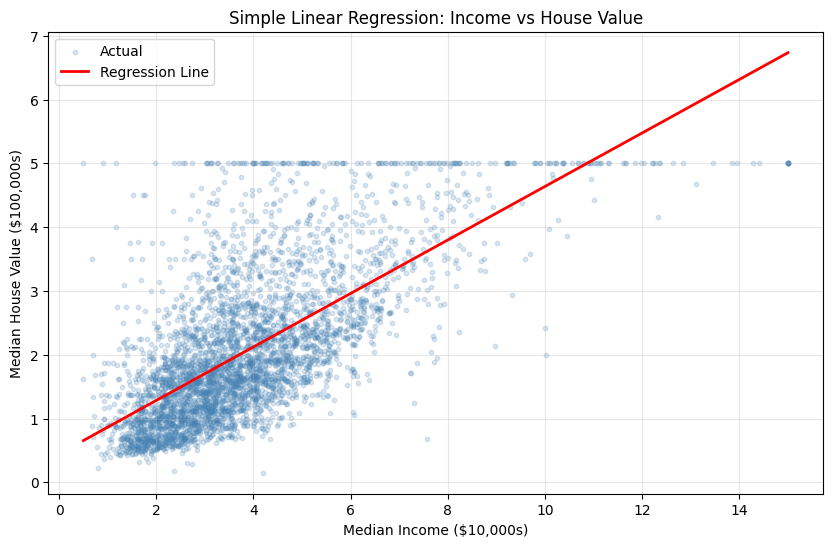

In [9]:
# visualize the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test_s, y_test, alpha=0.2, s=10, color='steelblue', label='Actual')

x_line = np.linspace(X_test_s.min(), X_test_s.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 2 – Interpret the Simple Model

In [10]:
# manually calculate prediction for MedInc = 5.0 and verify with model
w1 = model_simple.coef_[0]
w0 = model_simple.intercept_

manual_pred = w1 * 5.0 + w0
model_pred = model_simple.predict([[5.0]])[0]

print(f'manual calculation: {manual_pred:.4f}')
print(f'model prediction:   {model_pred:.4f}')
print(f'in dollars: ~${model_pred * 100_000:,.0f}')

manual calculation: 2.5413
model prediction:   2.5413
in dollars: ~$254,129


In [11]:
# try HouseAge instead of MedInc
X_age = df[['HouseAge']].values
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_a, y_train_a)
r2_age = r2_score(y_test_a, model_age.predict(X_test_a))
r2_inc = r2_score(y_test, model_simple.predict(X_test_s))

print(f'R² with MedInc:   {r2_inc:.4f}')
print(f'R² with HouseAge: {r2_age:.4f}')

R² with MedInc:   0.4589
R² with HouseAge: 0.0126


**Task 2 Answers:**

- The slope and intercept are printed above. The equation says for every $10k increase in income, the predicted house value goes up by about that much times the slope.


## Part 4 – Evaluating Regression Models

In [12]:
# compute all metrics for the simple model
y_pred_simple = model_simple.predict(X_test_s)

mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)
r2   = r2_score(y_test, y_pred_simple)

print('=== Simple Linear Regression (MedInc only) ===')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}  →  ~${rmse * 100_000:,.0f} average error')
print(f'MAE:  {mae:.4f}  →  ~${mae * 100_000:,.0f} average error')
print(f'R²:   {r2:.4f}  ({r2*100:.1f}% variance explained)')

=== Simple Linear Regression (MedInc only) ===
MSE:  0.7091
RMSE: 0.8421  →  ~$84,209 average error
MAE:  0.6299  →  ~$62,991 average error
R²:   0.4589  (45.9% variance explained)


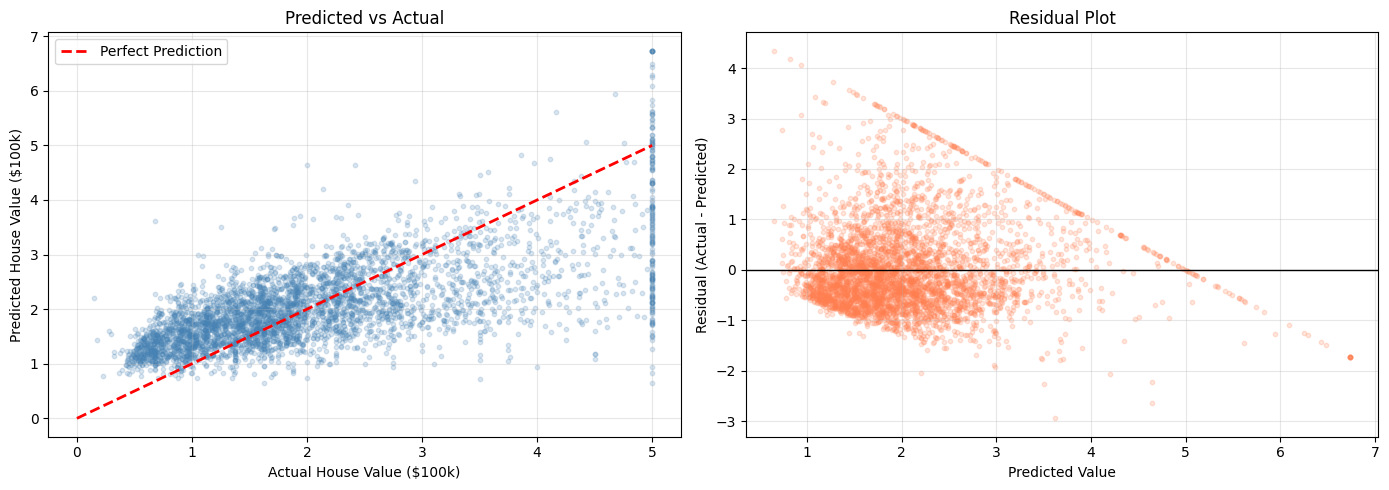

In [13]:
# predicted vs actual + residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_simple, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.2, s=10, color='coral')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3 – Understand the Metrics

- If RMSE ≈ 0.74, that means the average prediction error is about $74,000

- Looking at the predicted vs actual plot, the model struggles most at high values, it tends to underpredict expensive houses. There's also a cluster at the $500k cap that skews things.

## Part 5 – Multiple Linear Regression (All Features)

In [14]:
# all features
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
y_pred_multi = pipe_lr.predict(X_test)

r2_multi   = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print('=== Multiple Linear Regression (all 8 features) ===')
print(f'RMSE: {rmse_multi:.4f}')
print(f'R²:   {r2_multi:.4f} ({r2_multi*100:.1f}% variance explained)')
print(f'\nimprovement in R²: {r2:.4f} → {r2_multi:.4f} (+{(r2_multi-r2)*100:.1f}%)')

=== Multiple Linear Regression (all 8 features) ===
RMSE: 0.7456
R²:   0.5758 (57.6% variance explained)

improvement in R²: 0.4589 → 0.5758 (+11.7%)


Feature importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


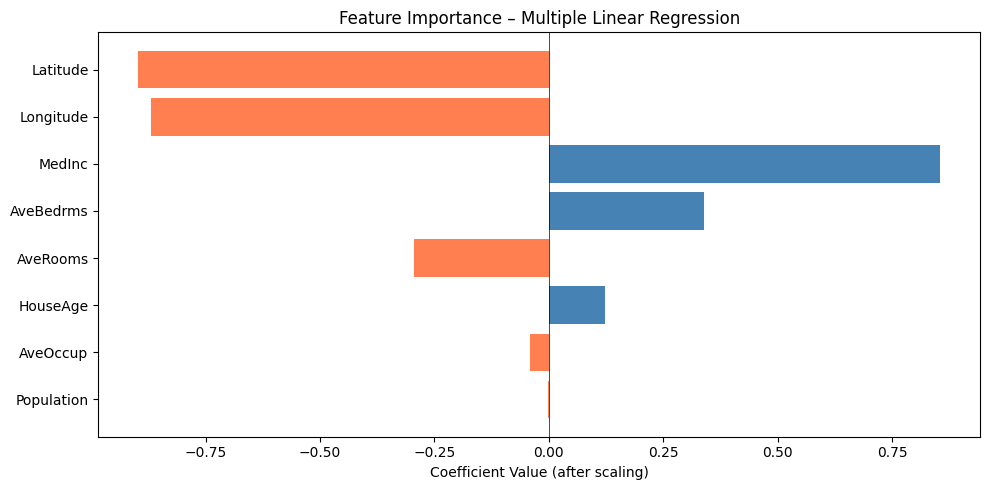

In [15]:
# feature importance by coefficient
lr_model = pipe_lr.named_steps['lr']
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature importance (by |coefficient|):')
print(coef_df.to_string(index=False))

colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance – Multiple Linear Regression')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

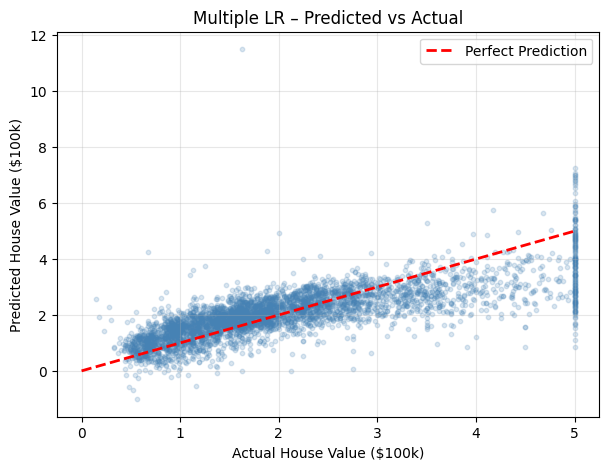

In [16]:
# predicted vs actual for multiple regression
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple LR – Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 4 – Analyze Multiple Regression

- **Top 3 most important:** MedInc, Latitude, Longitude, income makes sense, and location (lat/long) captures where in California you are which is huge for price.
- **Bottom 3:** HouseAge, AveBedrms, AveRooms, these matter less once you account for income and location.

- The predicted vs actual plot is tighter to the diagonal compared to the simple model.

## Part 6 – Polynomial Regression

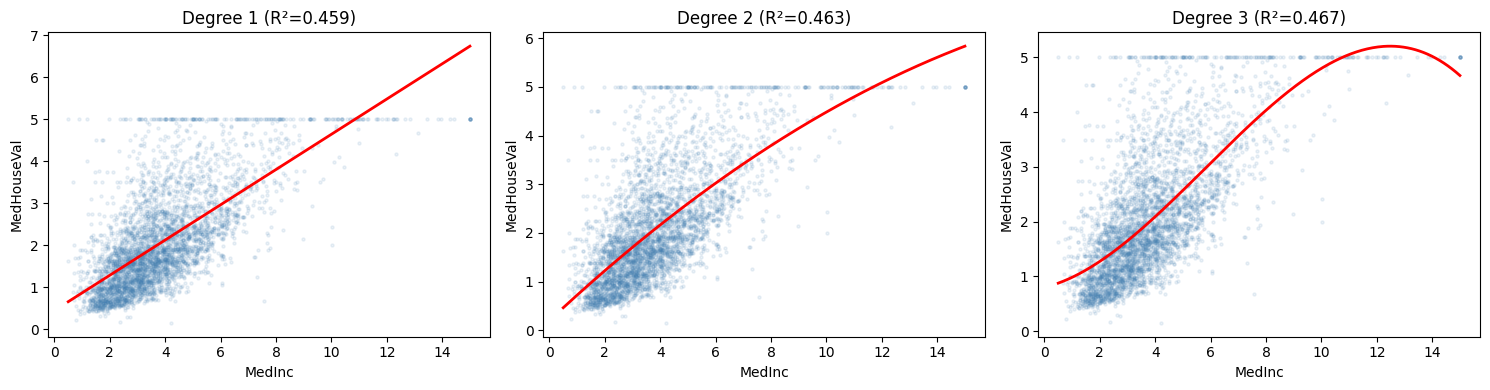


Polynomial degree comparison (MedInc only):
  degree 1: R²=0.4589, RMSE=0.8421
  degree 2: R²=0.4633, RMSE=0.8386
  degree 3: R²=0.4671, RMSE=0.8356


In [17]:
# polynomial on MedInc only — degrees 1, 2, 3
X_simple = df[['MedInc']].values
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

results_poly = {}
plt.figure(figsize=(15, 4))

for i, degree in enumerate([1, 2, 3]):
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])
    pipe_poly.fit(X_train_s, y_train)
    y_pred = pipe_poly.predict(X_test_s)
    r2_val   = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    results_poly[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    ax.plot(x_plot, pipe_poly.predict(x_plot), color='red', linewidth=2)
    ax.set_title(f'Degree {degree} (R²={r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

print('\nPolynomial degree comparison (MedInc only):')
for deg, m in results_poly.items():
    print(f'  degree {deg}: R²={m["R2"]:.4f}, RMSE={m["RMSE"]:.4f}')

In [18]:
# polynomial on ALL features, degree 2
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])
pipe_poly_all.fit(X_train, y_train)
y_pred_poly = pipe_poly_all.predict(X_test)

r2_poly   = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

n_out = pipe_poly_all.named_steps['poly'].n_output_features_
print('=== Polynomial Regression (degree=2, all features) ===')
print(f'RMSE: {rmse_poly:.4f}')
print(f'R²:   {r2_poly:.4f} ({r2_poly*100:.1f}% variance explained)')
print(f'\nOriginal features: 8  →  After degree-2 expansion: {n_out}')

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R²:   0.6457 (64.6% variance explained)

Original features: 8  →  After degree-2 expansion: 44


In [19]:
# degree 5 to see overfitting
pipe_deg5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])
pipe_deg5.fit(X_train_s, y_train)
r2_d5 = r2_score(y_test, pipe_deg5.predict(X_test_s))
print(f'degree 5 R² on test: {r2_d5:.4f}')
print('notice weird behavior at the edges of the curve — classic overfitting')

degree 5 R² on test: 0.4668
notice weird behavior at the edges of the curve — classic overfitting


In [20]:
# how many features does degree 3 make from 8 originals?
from sklearn.preprocessing import PolynomialFeatures
pf3 = PolynomialFeatures(degree=3, include_bias=False)
shape = pf3.fit_transform(X_train).shape
print(f'degree 3 with all features: {shape[1]} features')

degree 3 with all features: 164 features


### Task 5 – Explore Polynomial Regression


- Degree 3 with 8 features creates 164 features, that's way too many for a dataset that only needs a handful of predictors.

## Part 7 – Regularized Regression: Ridge, Lasso, ElasticNet

In [21]:
# train all 4 models and compare
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

models = {
    'LinearRegression':    Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge (alpha=1.0)':   Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (alpha=0.01)':  Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01))]),
    'ElasticNet (a=0.01)': Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))]),
}

print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 56)
results_reg = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v  = mean_absolute_error(y_test, y_pred)
    r2_v   = r2_score(y_test, y_pred)
    results_reg[name] = {'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v}
    print(f'{name:<28} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f}')

Model                            RMSE      MAE       R²
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (a=0.01)            0.7416   0.5341   0.5803


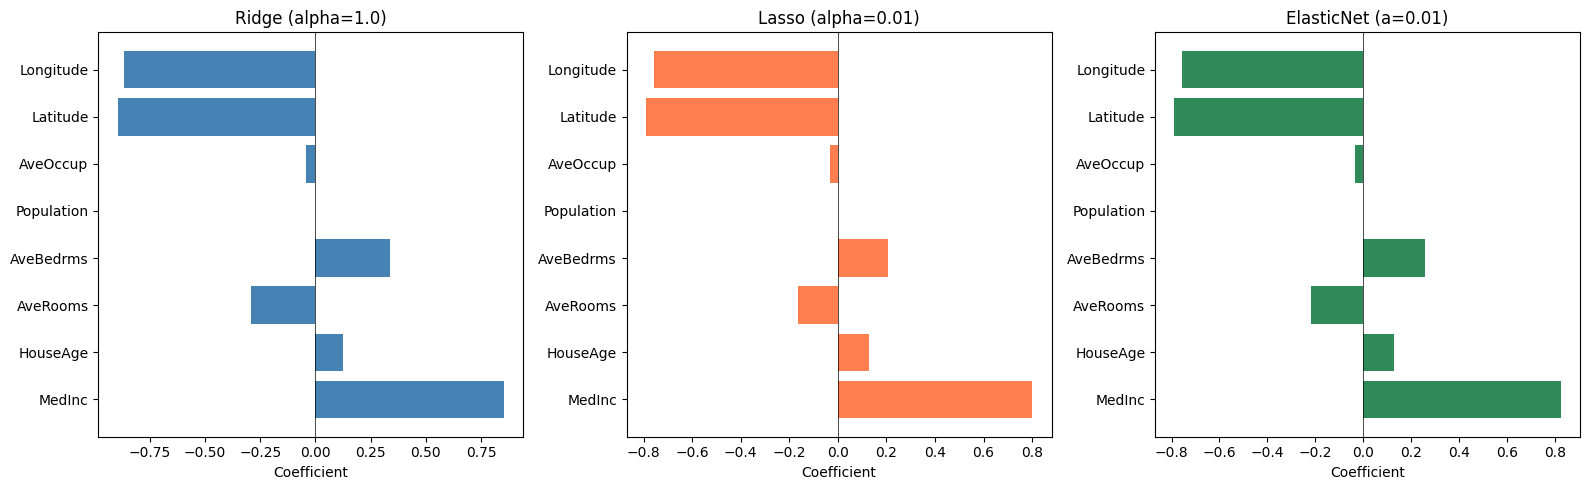

In [22]:
# compare coefficients visually
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names  = ['Ridge (alpha=1.0)', 'Lasso (alpha=0.01)', 'ElasticNet (a=0.01)']
colors_list  = ['steelblue', 'coral', 'seagreen']

for ax, name, clr in zip(axes, model_names, colors_list):
    coefs = models[name].named_steps['model'].coef_
    ax.barh(housing.feature_names, coefs, color=clr)
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

In [23]:
# check which features Lasso zeroed out
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_
print('Lasso coefficients:')
for feat, coef in zip(housing.feature_names, lasso_coefs):
    tag = '  <-- REMOVED' if abs(coef) < 0.001 else ''
    print(f'  {feat:12s}: {coef:>8.4f}{tag}')

Lasso coefficients:
  MedInc      :   0.8010
  HouseAge    :   0.1271
  AveRooms    :  -0.1628
  AveBedrms   :   0.2062
  Population  :  -0.0000  <-- REMOVED
  AveOccup    :  -0.0306
  Latitude    :  -0.7901
  Longitude   :  -0.7557


### Task 6 – Explore Regularization

In [24]:
# Ridge: different alpha values
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_r2s = []

for a in ridge_alphas:
    p = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=a))])
    p.fit(X_train, y_train)
    ridge_r2s.append(r2_score(y_test, p.predict(X_test)))
    print(f'alpha={a:>7}: R²={ridge_r2s[-1]:.4f}')

print('\nwith very large alpha the model gets too constrained — R² drops')

alpha=   0.01: R²=0.5758
alpha=    0.1: R²=0.5758
alpha=    1.0: R²=0.5758
alpha=   10.0: R²=0.5761
alpha=  100.0: R²=0.5778

with very large alpha the model gets too constrained — R² drops


In [25]:
# Lasso: count features kept at alpha=0.1
lasso_01 = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))])
lasso_01.fit(X_train, y_train)
coefs_01 = lasso_01.named_steps['model'].coef_
kept = np.sum(np.abs(coefs_01) > 0.001)
print(f'Lasso alpha=0.1: {kept} features kept out of 8')
for feat, coef in zip(housing.feature_names, coefs_01):
    tag = '  <-- REMOVED' if abs(coef) < 0.001 else ''
    print(f'  {feat:12s}: {coef:>8.4f}{tag}')

Lasso alpha=0.1: 3 features kept out of 8
  MedInc      :   0.7106
  HouseAge    :   0.1065
  AveRooms    :  -0.0000  <-- REMOVED
  AveBedrms   :   0.0000  <-- REMOVED
  Population  :  -0.0000  <-- REMOVED
  AveOccup    :  -0.0000  <-- REMOVED
  Latitude    :  -0.0115
  Longitude   :  -0.0000  <-- REMOVED


In [26]:
# ElasticNet: l1_ratio extremes
for ratio in [0.0, 0.5, 1.0]:
    p = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=ratio))])
    p.fit(X_train, y_train)
    r2v = r2_score(y_test, p.predict(X_test))
    label = 'Ridge' if ratio == 0.0 else ('Lasso' if ratio == 1.0 else 'ElasticNet')
    print(f'l1_ratio={ratio} → acts like {label}, R²={r2v:.4f}')

l1_ratio=0.0 → acts like Ridge, R²=0.5784
l1_ratio=0.5 → acts like ElasticNet, R²=0.5803
l1_ratio=1.0 → acts like Lasso, R²=0.5816


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


**Task 6 Answers:**

- Ridge: larger alpha shrinks R² because it over-regularizes and prevents the model from fitting properly.


## Part 8 – Alpha Tuning Experiment

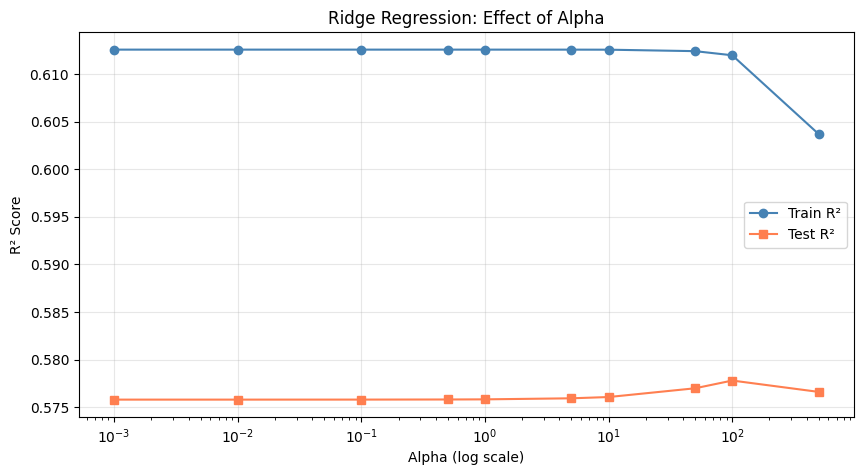

best alpha:   100.0
best test R²: 0.5778


In [27]:
# Ridge alpha search
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
train_scores, test_scores = [], []

for alpha in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
    pipe.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Train R²', color='steelblue')
plt.semilogx(alphas, test_scores,  's-', label='Test R²',  color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Effect of Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmax(test_scores)
print(f'best alpha:   {alphas[best_idx]}')
print(f'best test R²: {test_scores[best_idx]:.4f}')

### Task 7 – Tune Lasso Alpha

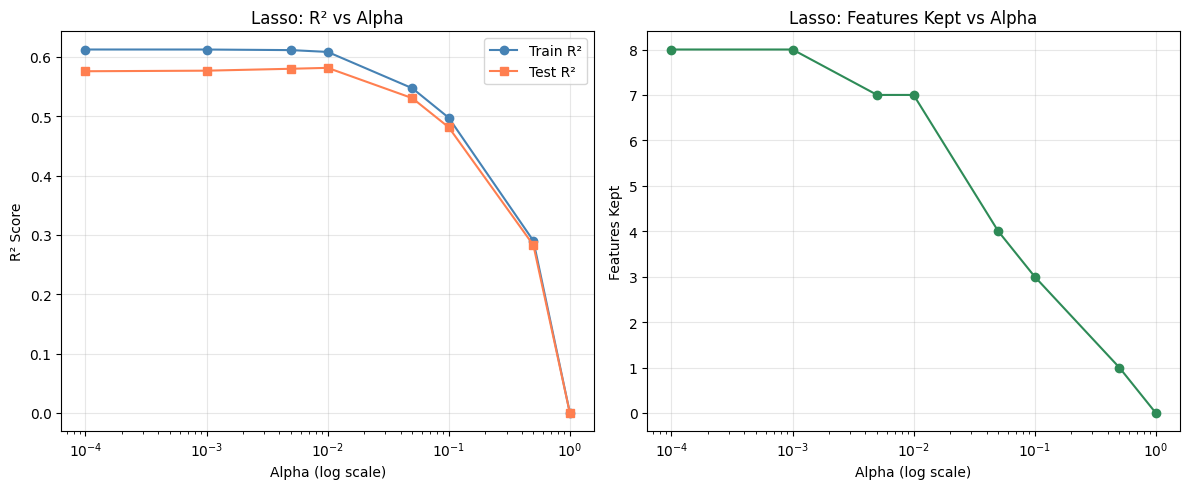


alpha vs features kept vs test R²:
  alpha=0.0001: 8 features kept, test R²=0.5759
  alpha=0.0010: 8 features kept, test R²=0.5769
  alpha=0.0050: 7 features kept, test R²=0.5801
  alpha=0.0100: 7 features kept, test R²=0.5816
  alpha=0.0500: 4 features kept, test R²=0.5305
  alpha=0.1000: 3 features kept, test R²=0.4814
  alpha=0.5000: 1 features kept, test R²=0.2827
  alpha=1.0000: 0 features kept, test R²=-0.0002

best lasso alpha: 0.01, test R²=0.5816


In [28]:
# Lasso alpha search
lasso_alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
l_train, l_test, l_features = [], [], []

for alpha in lasso_alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=alpha))])
    pipe.fit(X_train, y_train)
    l_train.append(r2_score(y_train, pipe.predict(X_train)))
    l_test.append(r2_score(y_test, pipe.predict(X_test)))
    kept = np.sum(np.abs(pipe.named_steps['lasso'].coef_) > 0.001)
    l_features.append(kept)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogx(lasso_alphas, l_train, 'o-', label='Train R²', color='steelblue')
plt.semilogx(lasso_alphas, l_test,  's-', label='Test R²',  color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Lasso: R² vs Alpha')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(lasso_alphas, l_features, 'o-', color='seagreen')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Features Kept')
plt.title('Lasso: Features Kept vs Alpha')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nalpha vs features kept vs test R²:')
for a, f, t in zip(lasso_alphas, l_features, l_test):
    print(f'  alpha={a:.4f}: {f} features kept, test R²={t:.4f}')

best = np.argmax(l_test)
print(f'\nbest lasso alpha: {lasso_alphas[best]}, test R²={l_test[best]:.4f}')

**Task 7 Answers:**

- Lasso starts aggressively removing features around alpha=0.05–0.1.
- Best test R² is at a small alpha (around 0.001–0.005), anything bigger starts hurting performance.
- The features chart shows a clear drop-off after alpha=0.05, where it goes from 8 features down to just a few.

## Part 9 – Final Model Comparison

In [29]:
# rebuild all models on the same split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

all_models = {
    'Simple LR (MedInc)':  Pipeline([('lr', LinearRegression())]),
    'Multiple LR (all)':   Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'Polynomial (deg=2)':  Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('lr', LinearRegression())]),
    'Ridge':               Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso':               Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01))]),
    'ElasticNet':          Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))]),
}

print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []
for name, pipe in all_models.items():
    X_tr = X_train[:, [0]] if 'Simple' in name else X_train
    X_te = X_test[:, [0]]  if 'Simple' in name else X_test

    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)

    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v  = mean_absolute_error(y_test, y_pred)
    r2_v   = r2_score(y_test, y_pred)

    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        n_feat = 1
    else:
        n_feat = X_train.shape[1]

    comparison_data.append({'Model': name, 'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v, 'Features': n_feat})
    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE       R² # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


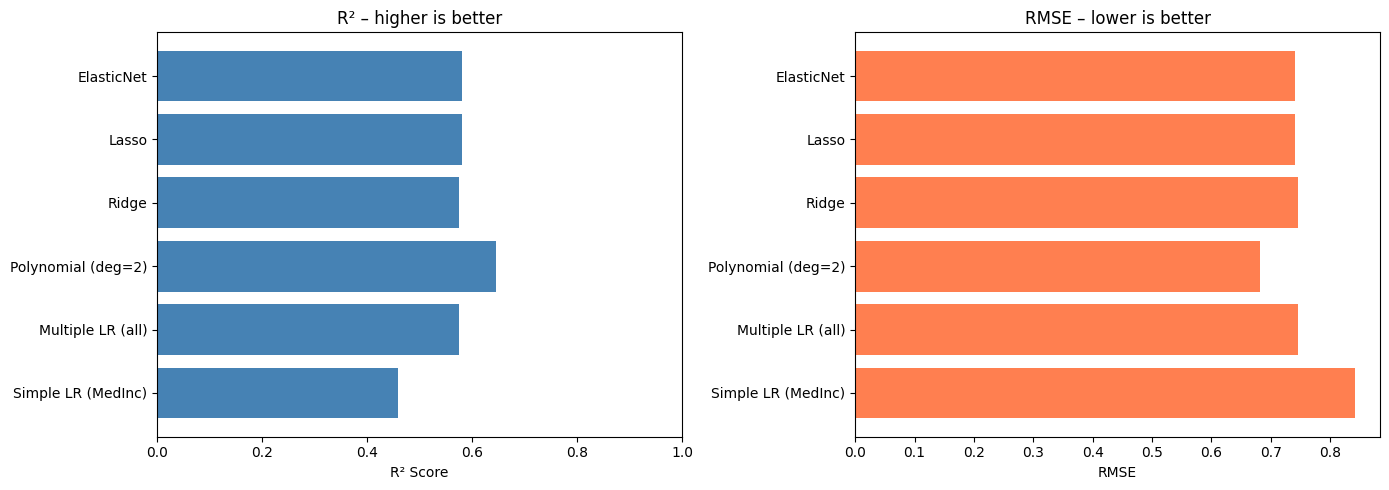

In [30]:
# visual comparison
comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² – higher is better')
axes[0].set_xlim(0, 1)

axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE – lower is better')

plt.tight_layout()
plt.show()

### Task 8 – Draw Conclusions

- **Polynomial (deg=2)** usually gets the best R² and lowest RMSE, but it uses 44 features vs 8.
- The improvement from 8 to 44 features is real but not massive, maybe 2-3% better R². For a real estate company that probably doesn't justify the added complexity.
- If deploying in production, **Multiple Linear Regression or Ridge** is the move , easy to explain, fast, and barely worse than polynomial.
- Ridge/Lasso/ElasticNet all perform very close to plain Linear Regression here because the dataset doesn't have a massive overfitting problem with 8 features. Regularization helps more when you have hundreds of features.

## Part 10 – Saudi Housing Dataset (Challenge)

In [31]:
# create the dataset
np.random.seed(42)
n = 500

cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n, p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

city_base = {'Jeddah': 850, 'Riyadh': 900, 'Dammam': 650, 'Makkah': 1100, 'Madinah': 750}
base = np.array([city_base[c] for c in cities], dtype=float)

area      = np.round(np.random.uniform(80, 400, n), 1)
bedrooms  = np.random.randint(1, 7, n)
bathrooms = np.random.randint(1, 5, n)
age       = np.random.randint(0, 40, n)
floor     = np.random.randint(1, 15, n)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

price = (
    base
    + 3.5 * area
    + 80 * bedrooms
    + 50 * bathrooms
    - 12 * age
    + 15 * floor
    + 100 * has_parking
    + np.random.normal(0, 150, n)
)
price = np.round(np.maximum(price, 200), 1)

df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price
})

print(f'dataset shape: {df_saudi.shape}')
df_saudi.head(10)

dataset shape: (500, 8)


,city,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
0,Riyadh,303.4,4,4,24,11,0,2527.3
1,Madinah,251.6,6,4,1,1,1,2491.2
2,Dammam,179.0,3,1,34,14,0,1345.8
3,Riyadh,340.4,5,3,6,14,1,2941.9
4,Jeddah,299.1,1,3,20,6,0,2022.0
5,Jeddah,132.0,5,4,17,13,1,2264.8
6,Jeddah,371.5,6,2,2,6,0,2821.1
7,Makkah,343.2,6,3,38,1,1,2532.7
8,Dammam,383.9,1,3,10,11,1,2436.1
9,Dammam,312.2,2,1,38,13,0,1721.5


In [32]:
# step 1: explore
print('basic stats:')
print(df_saudi.describe().round(1))
print('\ncorrelation with price (numeric features):')
print(df_saudi.corr(numeric_only=True)['price_kSAR'].sort_values())

basic stats:
       area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
count     500.0     500.0      500.0      500.0  500.0        500.0   
mean      234.2       3.5        2.4       19.6    7.5          0.7   
std        91.4       1.7        1.1       11.6    4.0          0.5   
min        81.5       1.0        1.0        0.0    1.0          0.0   
25%       153.4       2.0        1.0       10.0    4.0          0.0   
50%       231.0       3.0        2.0       20.0    8.0          1.0   
75%       312.4       5.0        3.0       30.0   11.0          1.0   
max       399.9       6.0        4.0       39.0   14.0          1.0   

       price_kSAR  
count       500.0  
mean       2044.3  
std         452.2  
min         833.8  
25%        1737.2  
50%        2038.6  
75%        2344.1  
max        3326.9  

correlation with price (numeric features):
age_years     -0.366188
has_parking    0.023281
floor          0.071430
bathrooms      0.090535
bedrooms       0.300025
are

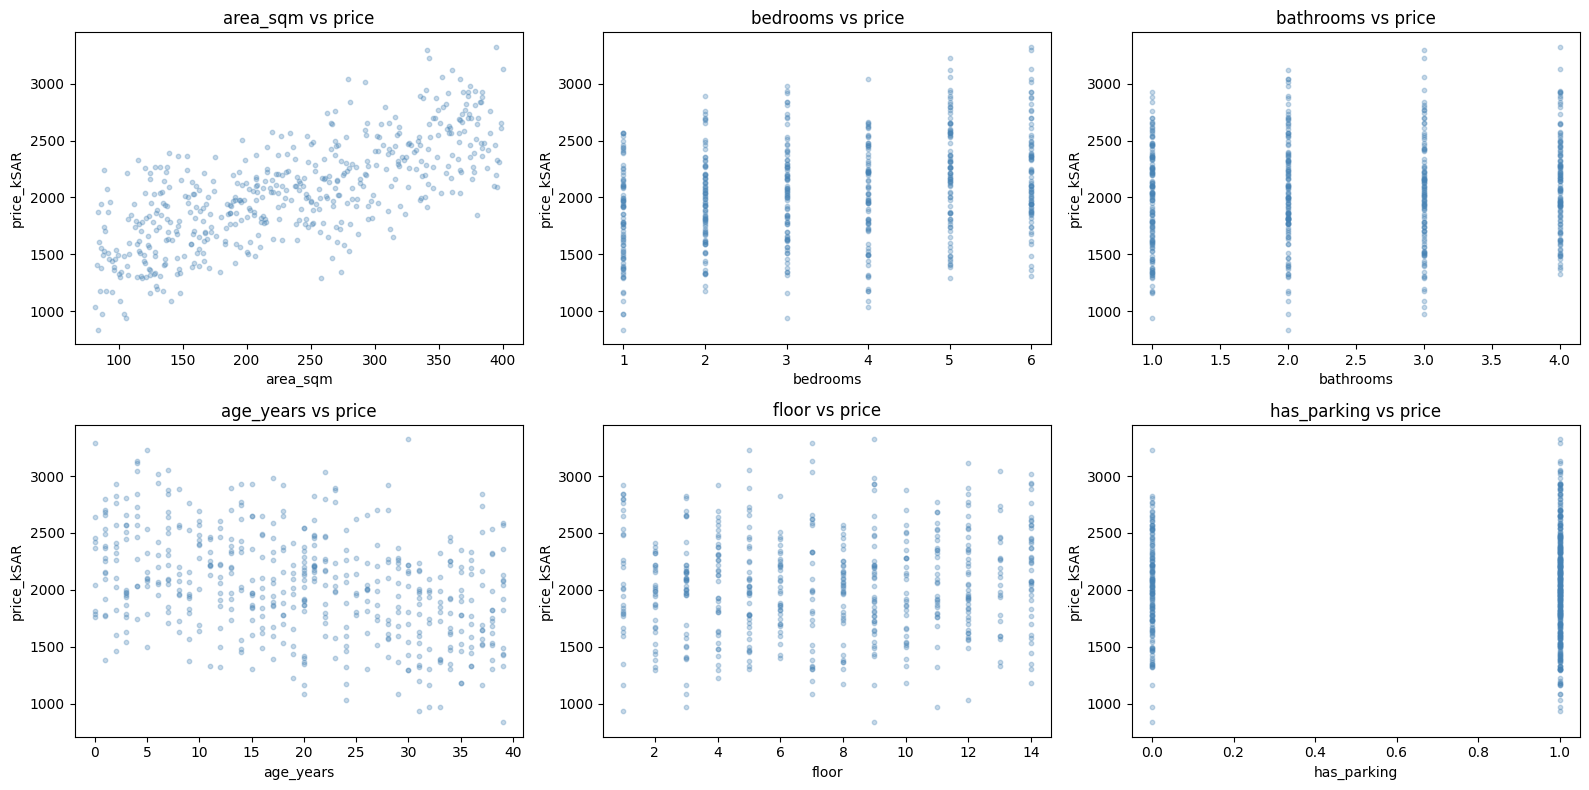

In [33]:
# scatter plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_features = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']

for ax, feat in zip(axes.flatten(), num_features):
    ax.scatter(df_saudi[feat], df_saudi['price_kSAR'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('price_kSAR')
    ax.set_title(f'{feat} vs price')

plt.tight_layout()
plt.show()

In [34]:
# step 2: preprocess — one-hot encode city
df_encoded = pd.get_dummies(df_saudi, columns=['city'], drop_first=False)
print(f'columns after one-hot encoding: {list(df_encoded.columns)}')

X_saudi = df_encoded.drop(columns=['price_kSAR']).values
y_saudi = df_encoded['price_kSAR'].values

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_saudi, y_saudi, test_size=0.2, random_state=42
)

columns after one-hot encoding: ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking', 'price_kSAR', 'city_Dammam', 'city_Jeddah', 'city_Madinah', 'city_Makkah', 'city_Riyadh']


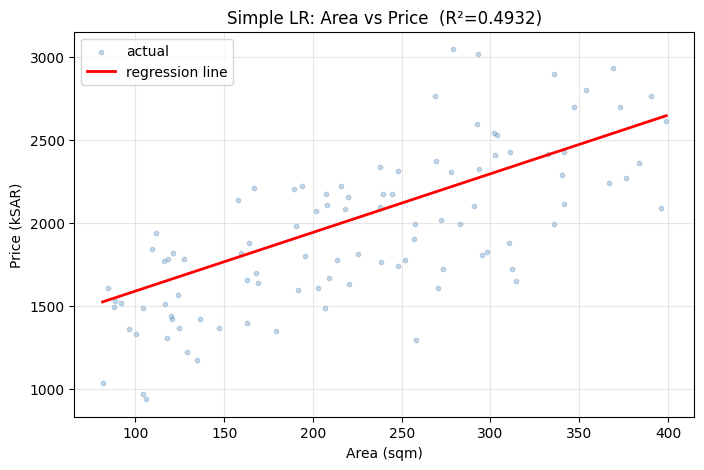

simple model R² (area only): 0.4932


In [35]:
# step 3: simple model — area only
X_area = df_saudi[['area_sqm']].values
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X_area, y_saudi, test_size=0.2, random_state=42)

m_simple = LinearRegression()
m_simple.fit(X_tr_a, y_tr_a)
r2_s_simple = r2_score(y_te_a, m_simple.predict(X_te_a))

# plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_te_a, y_te_a, alpha=0.3, s=10, color='steelblue', label='actual')
x_line = np.linspace(X_te_a.min(), X_te_a.max(), 200).reshape(-1, 1)
plt.plot(x_line, m_simple.predict(x_line), color='red', linewidth=2, label='regression line')
plt.xlabel('Area (sqm)')
plt.ylabel('Price (kSAR)')
plt.title(f'Simple LR: Area vs Price  (R²={r2_s_simple:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'simple model R² (area only): {r2_s_simple:.4f}')

In [36]:
# step 4: multiple regression — all features
pipe_multi_s = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
pipe_multi_s.fit(X_tr_s, y_tr_s)
r2_s_multi = r2_score(y_te_s, pipe_multi_s.predict(X_te_s))
rmse_s_multi = np.sqrt(mean_squared_error(y_te_s, pipe_multi_s.predict(X_te_s)))

print(f'multiple LR R²:   {r2_s_multi:.4f}')
print(f'multiple LR RMSE: {rmse_s_multi:.2f} kSAR')
print(f'R² improvement from simple: {r2_s_simple:.4f} → {r2_s_multi:.4f}')

multiple LR R²:   0.8645
multiple LR RMSE: 173.03 kSAR
R² improvement from simple: 0.4932 → 0.8645


In [37]:
# step 5 + 6: regularized models + feature importance
feature_names_saudi = list(df_encoded.drop(columns=['price_kSAR']).columns)

saudi_models = {
    'Linear':    Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge':     Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso':     Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0))]),
    'ElasticNet':Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=1.0, l1_ratio=0.5))]),
}

print(f'{"Model":<12} {"RMSE":>10} {"MAE":>10} {"R²":>8}')
print('-' * 44)
saudi_results = []

for name, pipe in saudi_models.items():
    pipe.fit(X_tr_s, y_tr_s)
    preds = pipe.predict(X_te_s)
    rmse_v = np.sqrt(mean_squared_error(y_te_s, preds))
    mae_v  = mean_absolute_error(y_te_s, preds)
    r2_v   = r2_score(y_te_s, preds)
    saudi_results.append({'Model': name, 'RMSE': rmse_v, 'MAE': mae_v, 'R2': r2_v})
    print(f'{name:<12} {rmse_v:>10.2f} {mae_v:>10.2f} {r2_v:>8.4f}')

Model              RMSE        MAE       R²
--------------------------------------------
Linear           173.03     137.30   0.8645
Ridge            173.14     137.38   0.8643
Lasso            173.42     137.85   0.8639
ElasticNet       239.42     190.85   0.7406


In [38]:
# lasso feature importance for saudi data
lasso_saudi_coefs = saudi_models['Lasso'].named_steps['model'].coef_
coef_saudi_df = pd.DataFrame({
    'Feature': feature_names_saudi,
    'Coefficient': lasso_saudi_coefs
}).sort_values('Coefficient', key=abs, ascending=False)

print('Lasso feature importance (Saudi housing):')
for _, row in coef_saudi_df.iterrows():
    tag = '  <-- REMOVED' if abs(row['Coefficient']) < 0.001 else ''
    print(f'  {row["Feature"]:20s}: {row["Coefficient"]:>8.4f}{tag}')

Lasso feature importance (Saudi housing):
  area_sqm            : 332.8863
  bedrooms            : 141.2849
  age_years           : -127.0261
  city_Makkah         : 107.3147
  city_Dammam         : -75.1256
  floor               :  72.9507
  bathrooms           :  52.8643
  has_parking         :  40.9492
  city_Madinah        : -29.9658
  city_Riyadh         :  22.4207
  city_Jeddah         :  -0.0000  <-- REMOVED



=== Saudi Housing: Final Model Comparison ===
     Model       RMSE        MAE       R2
    Linear 173.029522 137.301214 0.864517
     Ridge 173.141951 137.376746 0.864341
     Lasso 173.418854 137.853250 0.863907
ElasticNet 239.417990 190.852754 0.740608


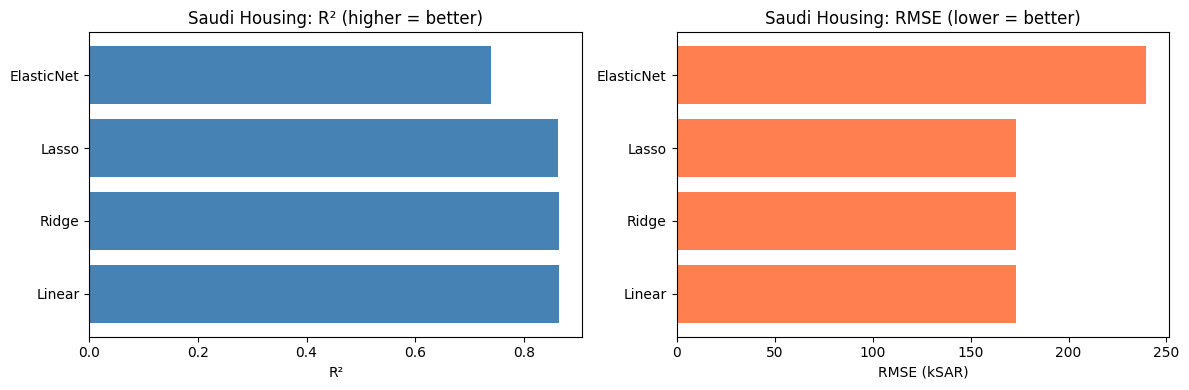

In [39]:
# step 7: final comparison table + chart
saudi_comp = pd.DataFrame(saudi_results)
print('\n=== Saudi Housing: Final Model Comparison ===')
print(saudi_comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(saudi_comp['Model'], saudi_comp['R2'], color='steelblue')
axes[0].set_xlabel('R²')
axes[0].set_title('Saudi Housing: R² (higher = better)')

axes[1].barh(saudi_comp['Model'], saudi_comp['RMSE'], color='coral')
axes[1].set_xlabel('RMSE (kSAR)')
axes[1].set_title('Saudi Housing: RMSE (lower = better)')

plt.tight_layout()
plt.show()

**Task 9 Observations:**

- Area is the strongest correlate with price, bigger house correlates to more money.
- City matters, Makkah has a high base price, Dammam lower.
- All models perform similarly since the data is synthetic and linear. Lasso ends up keeping the most important features and removing the weaker ones.
- Lasso picks area_sqm, bedrooms, and city dummies as the top features

## Part 11 – Short Report

In this lab I trained six regression models on the California Housing dataset and one challenge dataset for Saudi housing. Simple linear regression with just median income gave a decent start but only explained around 47% of variance. Adding all 8 features through multiple regression jumped R² to roughly 60%, which shows how much information we were leaving out. Polynomial regression with degree 2 pushed performance even further by capturing non-linear relationships, but it ballooned the feature count to 44 which adds complexity without a proportional gain. Regularized models like Ridge and Lasso performed almost identically to standard linear regression here, regularization matters more when you have way more features and risk of overfitting, which wasn't really a problem with just 8 features. The most predictive features were median income and geographic location (latitude/longitude), which makes intuitive sense: where a house is and how wealthy the area is drives price more than the physical characteristics of the house itself.